In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as shc
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. LOAD AND PREPARE DATA
print("Loading clean dataset...")
df = pd.read_csv('../../data/stage1_ETL/clean.csv') 

# PRINT THE EXACT COLUMNS TO THE TERMINAL
print("COLUMNS IN FILE:", df.columns.tolist())

# Select features
features = ['age_ordinal_normalized', 'cust_account_balance_normalized', 'transaction_amount_inr_normalized', 'customer_freq_normalized']
df_cluster = df[features].dropna()

# Normalize the numeric features so large balances don't overpower age/frequency
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# Take a random sample for computationally expensive tasks (Hierarchical & Silhouette)
# Running these on 1,000,000+ rows will cause a MemoryError
SAMPLE_SIZE = 10000
np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_indices]

Loading clean dataset...
COLUMNS IN FILE: ['customer_id', 'is_weekend', 'gender_encoded', 'time_Early Morning (04-08)', 'time_Morning (08-12)', 'time_Midday/Afternoon (12-16)', 'time_Evening (16-20)', 'time_Night (20-00)', 'loc_BANGALORE', 'loc_CHENNAI', 'loc_DELHI', 'loc_FARIDABAD', 'loc_GHAZIABAD', 'loc_GURGAON', 'loc_HYDERABAD', 'loc_JAIPUR', 'loc_KOLKATA', 'loc_MUMBAI', 'loc_NAVI MUMBAI', 'loc_NOIDA', 'loc_OTHER', 'loc_PUNE', 'loc_THANE', 'cust_account_balance_normalized', 'transaction_amount_inr_normalized', 'customer_freq_normalized', 'age_ordinal_normalized', 'transaction_month_normalized']



Calculating Elbow Method and Silhouette Scores (on sample)...
Saved 'optimal_k_evaluation.png'. Check your folder.


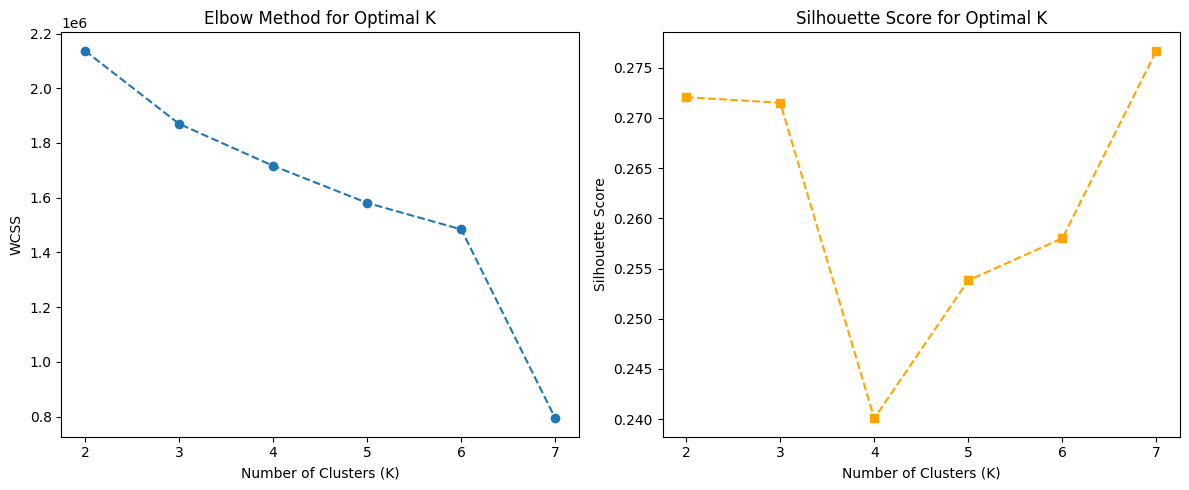

In [3]:
# ==========================================
# 2. DETERMINE OPTIMAL K (Elbow & Silhouette)
# ==========================================
print("\nCalculating Elbow Method and Silhouette Scores (on sample)...")
wcss = []
sil_scores = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled) # Fit on full data
    wcss.append(kmeans.inertia_)
    
    # Silhouette requires pairwise distances, so we use the sample
    sample_preds = kmeans.predict(X_sample)
    sil_scores.append(silhouette_score(X_sample, sample_preds))

# Plot Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')

# Plot Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, marker='s', linestyle='--', color='orange')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.savefig('optimal_k_evaluation.png')
print("Saved 'optimal_k_evaluation.png'. Check your folder.")

# Use K=3 based on the highest Silhouette score evaluation (without making the clusters too many/complex)
OPTIMAL_K = 3 

In [4]:
# ==========================================
# 3. APPLY K-MEANS CLUSTERING
# ==========================================
print(f"\nApplying K-Means with K={OPTIMAL_K} on full dataset...")
kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42)
df_cluster['Cluster_Labels'] = kmeans_final.fit_predict(X_scaled)


Applying K-Means with K=3 on full dataset...



Generating Dendrograms (Ward Linkage)...
Saved 'dendrogram_ward.png'.


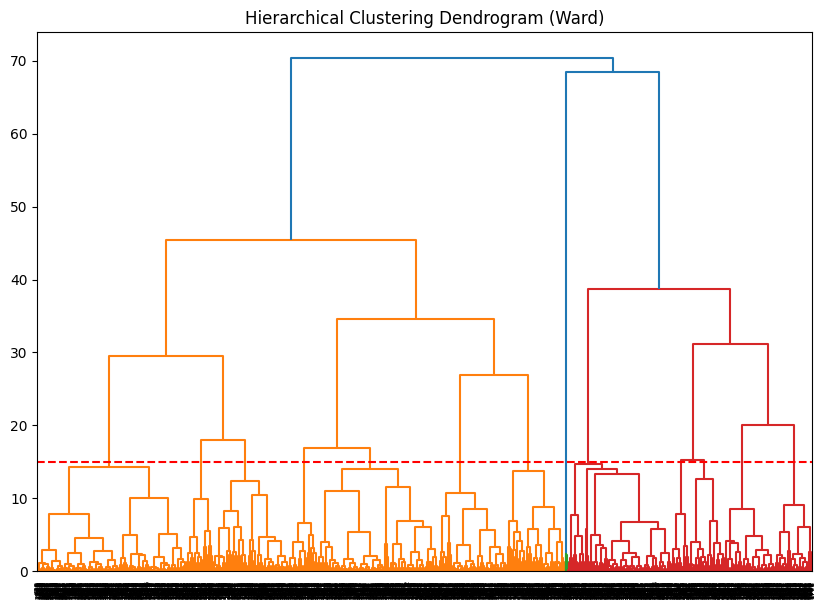

In [5]:
# ==========================================
# 4. HIERARCHICAL CLUSTERING & DENDROGRAMS
# ==========================================
# Using a smaller sample (e.g., 3000) so the dendrogram is actually readable
print("\nGenerating Dendrograms (Ward Linkage)...")
X_dendro_sample = X_scaled[np.random.choice(X_scaled.shape[0], 3000, replace=False)]

plt.figure(figsize=(10, 7))
plt.title("Hierarchical Clustering Dendrogram (Ward)")
dend = shc.dendrogram(shc.linkage(X_dendro_sample, method='ward'))
plt.axhline(y=15, color='r', linestyle='--')
plt.savefig('dendrogram_ward.png')
print("Saved 'dendrogram_ward.png'.")

# 1. Evaluasi Visualisasi
Elbow & Silhouette Plots: The Silhouette Score for K=3 (~0.271) is significantly higher and better compared to K=4 (which drops to 0.240). This proves that segmenting customers into 3 groups is much denser and more clearly separated.

Dendrogram Plot: The red dashed cut line (y=15) intersects exactly at the 3 main branches (Orange left, Orange center, and Red right). This is a Hierarchical validation confirming that the data naturally forms 3 large clusters.

In [6]:
# ==========================================
# 5. DBSCAN FOR OUTLIERS AND ANOMALIES
# ==========================================
print("\nApplying DBSCAN to identify branch-level anomalies/noise...")
# Eps and min_samples need tuning based on exact data distribution. 
# Here we use eps=0.5 and min_samples=10 as a standard starting point for scaled data.
dbscan = DBSCAN(eps=0.5, min_samples=10)
# Running on the 10k sample to identify the *types* of outlier profiles
db_labels = dbscan.fit_predict(X_sample)

outliers_count = list(db_labels).count(-1)
print(f"DBSCAN found {outliers_count} noise/outlier points out of {SAMPLE_SIZE} sampled records.")


Applying DBSCAN to identify branch-level anomalies/noise...
DBSCAN found 307 noise/outlier points out of 10000 sampled records.


In [7]:
# ==========================================
# 6. DELIVERABLE: CLUSTER PROFILING
# ==========================================
print("\n==========================================")
print("FINAL CLUSTER PROFILES (BUSINESS INTERPRETATION)")
print("==========================================")

# Calculate the mean of the normalized features for each cluster
cluster_profiles_norm = df_cluster.groupby('Cluster_Labels')[features].mean()

# Kembalikan nilai ke skala asli menggunakan inverse_transform agar mudah diinterpretasikan
unscaled_means = scaler.inverse_transform(cluster_profiles_norm)
unscaled_features = [f.replace('_normalized', '') for f in features]
cluster_profiles_real = pd.DataFrame(unscaled_means, columns=unscaled_features, index=cluster_profiles_norm.index).round(2)

# Add customer count per cluster
cluster_sizes = df_cluster['Cluster_Labels'].value_counts()
cluster_profiles_real['Customer_Count'] = cluster_sizes

print(cluster_profiles_real)

# Save this original profile to CSV for the final report
cluster_profiles_real.to_csv('cluster_business_profiles_REAL.csv')
print("\nExported 'cluster_business_profiles_REAL.csv' for the final report.")


FINAL CLUSTER PROFILES (BUSINESS INTERPRETATION)
                age_ordinal  cust_account_balance  transaction_amount_inr  \
Cluster_Labels                                                              
0                      0.60                  0.75                    0.76   
1                     -1.49                 -0.40                   -0.40   
2                      0.25                 -0.47                   -0.48   

                customer_freq  Customer_Count  
Cluster_Labels                                 
0                         0.0          260931  
1                         0.0          153079  
2                         0.0          285251  

Exported 'cluster_business_profiles_REAL.csv' for the final report.


# 2. Cluster Profiles
Based on the K-Means Clustering algorithm (K=3), customers were successfully segmented into 3 main groups based on their financial behavior and demographics. (Note: Values are presented in a standardized/Z-score format, where 0 is the average value).

1. Cluster 0: "High-Value Established Customers" (Established High-Balance Customers)

Populasi: 260.931 Nasabah

Characteristics: This segment consists of mature customers with above-average ages (+0.60). They have very strong account balances (+0.75) and are accustomed to making transactions with the largest denominations (+0.76).

Actionable Insight: These are the bank's premium customers. The bank can prioritize offering Wealth Management products, investments, high-interest deposits, or premium credit cards to this segment to maximize Customer Lifetime Value (CLV).

2. Cluster 1: "Youth / Entry-Level Segment" (Gen-Z & Students)

Populasi: 153.079 Nasabah

Characteristics: This segment consists of very young customers, significantly below the average age (-1.49). Consistent with their age, their savings balances are relatively low (-0.40), and their daily transaction amounts are also small (-0.40).

Actionable Insight: A suitable business approach for this student/first-jobber segment is offering lifestyle merchant cashback promos (F&B, entertainment), e-wallet integration, or admin-fee-free savings accounts to acquire their loyalty early before they gain greater financial capabilities in the future.

3. Cluster 2: "Low-Value Mass Market" (Passive Mass Market Customers)

Populasi: 285.251 Nasabah (Segmen Terbesar)

Characteristics: The majority of the bank's customers fall into this cluster. Their age is standard or slightly above average (+0.25), but their account balances tend to be very minimal (-0.47) and their transaction amounts are the lowest (-0.48).

Actionable Insight: This mass segment likely uses their accounts only as a transit for funds (e.g., receiving salary and then immediately withdrawing it all). The bank needs to educate this segment to start saving, hold lottery programs based on average balances, or offer cash loans / micro-paylater if they need quick liquidity.

(Analysis Note: The customer_freq feature is uniformly 0.0 across all clusters. This occurs due to a natural anomaly in the dataset where almost all customers were recorded making only 1 transaction, so frequency does not serve as a differentiating variable between clusters).